In [71]:
import pandas as pd
url = "https://data.wprdc.org/datastore/dump/00d74e83-8a23-486e-841b-286e1332a151"

# Imports dataset into notebook
df = pd.read_csv(url)

#Sorts dataset by neighborhood (alphabetically)
df_sort = df.sort_values(by='neighborhood')
df_sort

,_id,id,name,title,artist_name,art_type,park,image,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude
123,124,1790632922,WM00003000,Hampton Battery Memorial,Unknown,War Memorials,Allegheny Commons,https://tools.wprdc.org/images/pittsburgh/art_...,Allegheny Center,1.0,22.0,4.200356e+10,1.0,22.0,1.0,1-20,40.450890,-80.000960
54,55,1175269324,PA00049000,The Heavens,Sidney Waugh,Historic Art,NaN,NaN,Allegheny Center,1.0,22.0,4.200356e+10,1.0,22.0,1.0,1-6,40.452607,-80.006404
55,56,1971852534,PA00050000,The Earth,Sidney Waugh,Historic Art,NaN,NaN,Allegheny Center,1.0,22.0,4.200356e+10,1.0,22.0,1.0,1-6,40.452607,-80.006107
56,57,1492179153,PA00051000,Night,Sidney Waugh,Historic Art,NaN,NaN,Allegheny Center,1.0,22.0,4.200356e+10,1.0,22.0,1.0,1-6,40.452908,-80.006603
57,58,1663151283,PA00052000,Day,Sidney Waugh,Historic Art,NaN,NaN,Allegheny Center,1.0,22.0,4.200356e+10,1.0,22.0,1.0,1-6,40.453007,-80.006107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,91,431608558,PA00107002,Lawrenceville Life Links,JoAnna Commandaros,Modern and Contemporary Art,NaN,NaN,Upper Lawrenceville,7.0,10.0,4.200310e+10,2.0,10.0,2.0,3-5,40.479358,-79.954913
185,186,1597478051,WM00068000,War Memorial (West End),NaN,War Memorials,NaN,NaN,West End,2.0,20.0,4.200356e+10,5.0,20.0,6.0,1-17,40.440180,-80.034215
17,18,1873659637,175,Police Department Zone 6 Mural,"Ed Wirkowski, Michael Kapeluck, & Robert Robinson",Modern and Contemporary Art,NaN,NaN,West End,2.0,20.0,4.200356e+10,5.0,20.0,6.0,1-17,40.442081,-80.032174
6,7,915929762,156,Windows of Light,Jane Haskell,Modern and Contemporary Art,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
#Prints top 5 neighborhoods based on the amount of art
df_counts = pd.crosstab(df['neighborhood'], df['art_type'])
df_counts['Total'] = df_counts.sum(axis=1)
top_5 = df_counts.nlargest(5, 'Total')
top_5.index.name = None
top_5

art_type,Historic Art,Individual and Historic Monuments,Modern and Contemporary Art,Non-City Owned,War Memorials,Total
Central Business District,2,12,7,1,5,27
Squirrel Hill South,4,11,2,0,3,20
Allegheny Center,8,4,2,0,4,18
Highland Park,5,2,3,0,0,10
South Side Flats,1,0,3,2,3,9


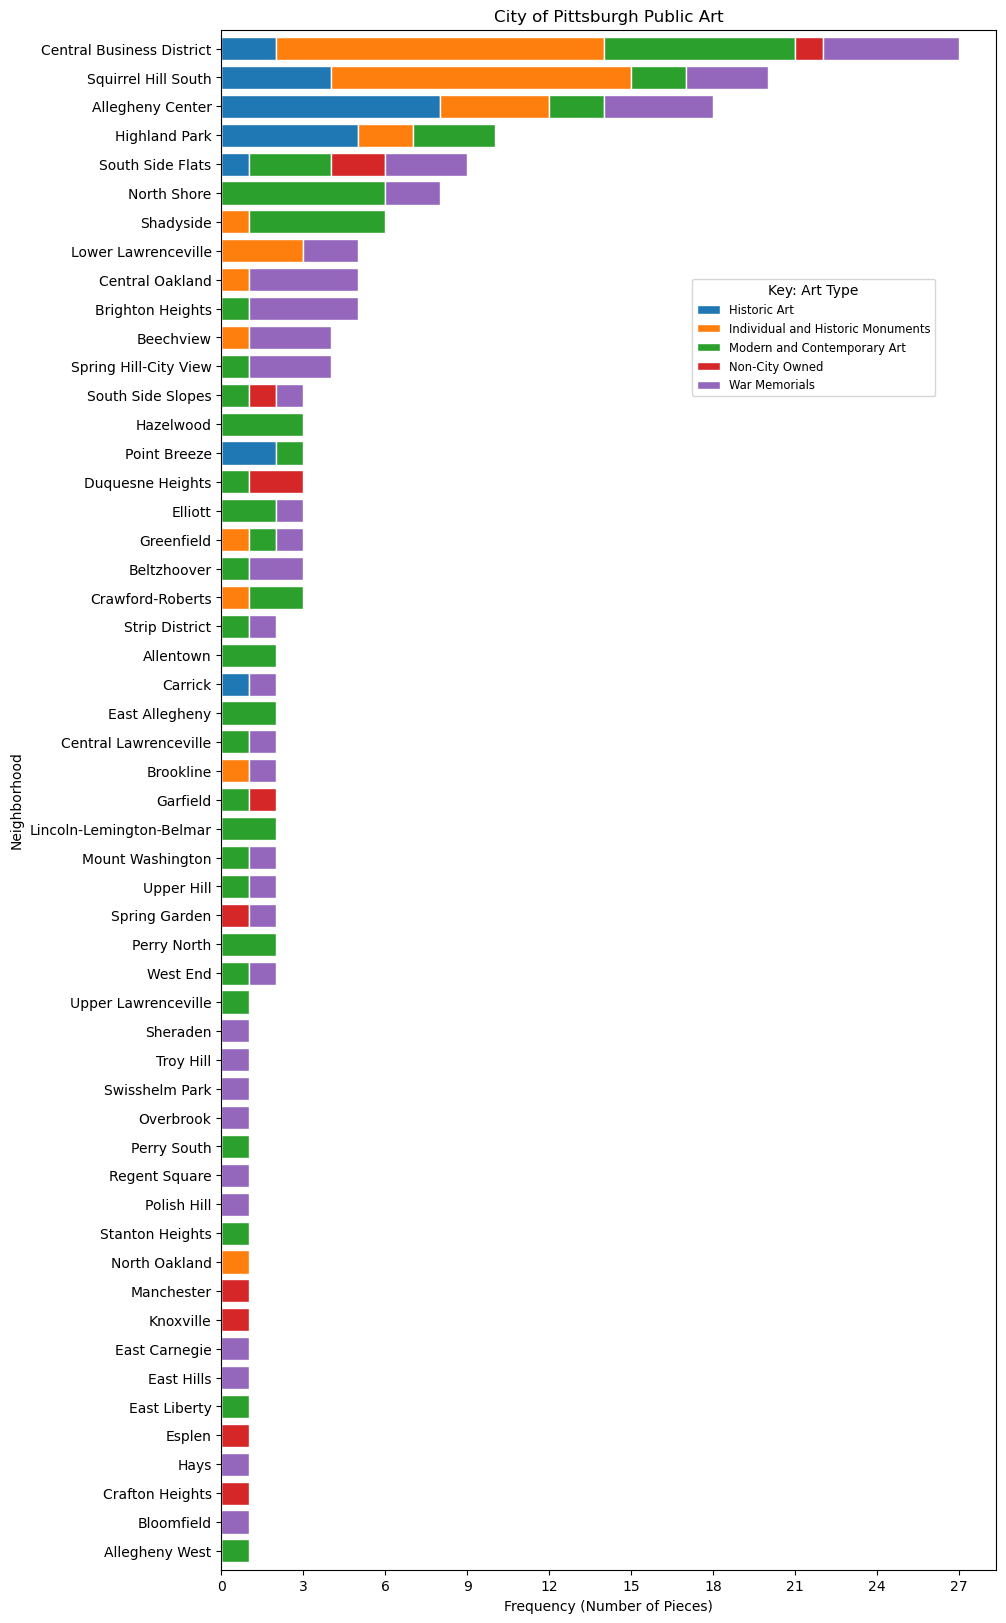

In [61]:
# Group the data by neighborhood, and the type of art 
art_pivot = pd.crosstab(df['neighborhood'], df['art_type'])

#Sort the data based on how much art each neighborhood has
art_pivot['Total Art'] = art_pivot.sum(axis=1)
sorted_art = art_pivot.sort_values(by='Total Art')

#Creates the graph
ax = sorted_art.drop(columns='Total Art').plot(
    kind='barh', 
    stacked=True, 
    figsize=(10, 20), 
    width=0.8,
    title="City of Pittsburgh Public Art",
    edgecolor='white'
)

#Makes bucket range of 3, instead of 5 (more inclusive in the graph)
ax.set_xticks(range(0, 30, 3))

#Labels the x and y axes
ax.set_xlabel("Frequency (Number of Pieces)")
ax.set_ylabel("Neighborhood")

#Moves the legend on the graph
ax.legend(title="Key: Art Type", loc='center left', bbox_to_anchor=(0.60, 0.80), fontsize='small')